# 99 — Results for Thesis

Aggregates all saved metrics into clean tables and figures ready for the thesis.

**No models are loaded or training is done here — everything is read from JSON files.**

## Prerequisites
Run these notebooks in order to generate all result files:

| Notebook | What it trains |
|----------|----------------|
| `10_train_text.ipynb` | BERT, DistilBERT |
| `11_train_audio.ipynb` | wav2vec2-base, DistilHuBERT |
| `12_train_face.ipynb` | ViT-B/16, MobileNetV3-Small |
| `20_eval_text.ipynb` | Text eval metrics |
| `21_eval_audio.ipynb` | Audio eval metrics |
| `22_eval_face.ipynb` | Face eval metrics |
| `30_late_fusion.ipynb` (COMBO="heavy") | Late fusion — heavy |
| `30_late_fusion.ipynb` (COMBO="light") | Late fusion — light |
| `31_intermediate_fusion.ipynb` (COMBO="heavy") | Intermediate fusion — heavy |
| `31_intermediate_fusion.ipynb` (COMBO="light") | Intermediate fusion — light |

Missing results are skipped gracefully.

In [18]:
import os, sys, json, warnings

_here = os.path.abspath(os.getcwd())
_root = _here if os.path.isdir(os.path.join(_here, 'src')) else os.path.abspath(os.path.join(_here, '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

from src.config import (
    EXP_ROOT, EXP_ROOT_AUDIO, EXP_ROOT_FACE, VERSION,
    MODELS_TO_RUN, AUDIO_MODELS_TO_RUN, FACE_MODELS_TO_RUN,
)
from src.training.utils import slugify

# ── Experiment directories ────────────────────────────────────────────────────
LATE_FUSION_ROOT  = f'../experiments/fusion/late/{VERSION}'
INTER_FUSION_ROOT = f'../experiments/fusion/intermediate/{VERSION}'
GATED_FUSION_ROOT = f'../experiments/fusion/gated/{VERSION}'

COMBOS = ['heavy', 'light']
COMBO_LABELS = {
    'heavy': 'Heavy (BERT + wav2vec2 + ViT)',
    'light': 'Light (DistilBERT + DistilHuBERT + MobileNet)',
}

def load_json(path):
    with open(path, encoding='utf-8') as f:
        return json.load(f)

def safe_load_json(path, default=None):
    if os.path.exists(path):
        return load_json(path)
    return default

print(f'Experiment root : {os.path.abspath(EXP_ROOT)}')
print(f'Late fusion dir : {os.path.abspath(LATE_FUSION_ROOT)}')
print(f'Interm. fusion  : {os.path.abspath(INTER_FUSION_ROOT)}')

Experiment root : e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\experiments\text_unimodal
Late fusion dir : e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\experiments\fusion\late\v1
Interm. fusion  : e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\experiments\fusion\intermediate\v1


---
## 1 — Unimodal Results

In [19]:
# ── Load unimodal metrics ─────────────────────────────────────────────────────
# Text and Audio share the same JSON structure:
#   train_metrics.json → { params: {total_params, trainable_params},
#                          best_epoch, best_dev_macro_f1, train_time_s,
#                          power: {avg_power_w, energy_kwh} }
#   eval_metrics.json  → { accuracy, macro_f1, weighted_f1,
#                          inference_ms_per_sample_bs1 }
#
# Face has a different (flat) structure:
#   train_metrics.json → { model_name, best_dev_macro_f1,
#                          total_params, trainable_params,
#                          training_time_s, avg_gpu_power_w, energy_kwh }
#   eval_metrics.json  → { model_name, accuracy, macro_f1, weighted_f1,
#                          num_test_utterances, num_test_frames,
#                          inference_ms_per_sample_bs1 }

records = []

# ── Text models ───────────────────────────────────────────────────────────────
for model_name in MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT, VERSION, slugify(model_name))
    train_path = os.path.join(run_dir, 'train_metrics.json')
    eval_path  = os.path.join(run_dir, 'eval_metrics.json')

    if not os.path.exists(train_path):
        print(f'  [skip] no train_metrics.json for {model_name}')
        continue

    tm = load_json(train_path)
    em = safe_load_json(eval_path, {})

    records.append({
        'modality':         'Text',
        'model':            model_name,
        'total_params_M':   round(tm['params']['total_params'] / 1e6, 3),
        'trainable_M':      round(tm['params']['trainable_params'] / 1e6, 3),
        'best_epoch':       tm.get('best_epoch', None),
        'best_dev_macro_f1': round(tm.get('best_dev_macro_f1', float('nan')), 4),
        'train_time_min':   round(tm.get('train_time_s', 0) / 60, 2),
        'avg_power_w':      round(tm.get('power', {}).get('avg_power_w', float('nan')), 2),
        'energy_kwh':       round(tm.get('power', {}).get('energy_kwh', float('nan')), 4),
        'test_accuracy':    round(em.get('accuracy', float('nan')), 4),
        'test_macro_f1':    round(em.get('macro_f1', float('nan')), 4),
        'test_weighted_f1': round(em.get('weighted_f1', float('nan')), 4),
        'infer_ms_bs1':     round(em.get('inference_ms_per_sample_bs1', float('nan')), 4),
    })

# ── Audio models ──────────────────────────────────────────────────────────────
for model_name in AUDIO_MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT_AUDIO, VERSION, slugify(model_name))
    train_path = os.path.join(run_dir, 'train_metrics.json')
    eval_path  = os.path.join(run_dir, 'eval_metrics.json')

    if not os.path.exists(train_path):
        print(f'  [skip] no train_metrics.json for {model_name}')
        continue

    tm = load_json(train_path)
    em = safe_load_json(eval_path, {})

    records.append({
        'modality':         'Audio',
        'model':            model_name,
        'total_params_M':   round(tm['params']['total_params'] / 1e6, 3),
        'trainable_M':      round(tm['params']['trainable_params'] / 1e6, 3),
        'best_epoch':       tm.get('best_epoch', None),
        'best_dev_macro_f1': round(tm.get('best_dev_macro_f1', float('nan')), 4),
        'train_time_min':   round(tm.get('train_time_s', 0) / 60, 2),
        'avg_power_w':      round(tm.get('power', {}).get('avg_power_w', float('nan')), 2),
        'energy_kwh':       round(tm.get('power', {}).get('energy_kwh', float('nan')), 4),
        'test_accuracy':    round(em.get('accuracy', float('nan')), 4),
        'test_macro_f1':    round(em.get('macro_f1', float('nan')), 4),
        'test_weighted_f1': round(em.get('weighted_f1', float('nan')), 4),
        'infer_ms_bs1':     round(em.get('inference_ms_per_sample_bs1', float('nan')), 4),
    })

# ── Face models ───────────────────────────────────────────────────────────────
# Face train_metrics has FLAT structure (no 'params' nesting, different key names)
for model_name in FACE_MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT_FACE, VERSION, slugify(model_name))
    train_path = os.path.join(run_dir, 'train_metrics.json')
    eval_path  = os.path.join(run_dir, 'eval_metrics.json')

    if not os.path.exists(train_path):
        print(f'  [skip] no train_metrics.json for {model_name}')
        continue

    tm = load_json(train_path)
    em = safe_load_json(eval_path, {})

    records.append({
        'modality':         'Face',
        'model':            model_name,
        'total_params_M':   round(tm.get('total_params', float('nan')) / 1e6, 3),
        'trainable_M':      round(tm.get('trainable_params', float('nan')) / 1e6, 3),
        'best_epoch':       None,  # face training logs don't record best_epoch
        'best_dev_macro_f1': round(tm.get('best_dev_macro_f1', float('nan')), 4),
        'train_time_min':   round(tm.get('training_time_s', 0) / 60, 2),
        'avg_power_w':      round(tm.get('avg_gpu_power_w', float('nan')), 2),
        'energy_kwh':       round(tm.get('energy_kwh', float('nan')), 4),
        'test_accuracy':    round(em.get('accuracy', float('nan')), 4),
        'test_macro_f1':    round(em.get('macro_f1', float('nan')), 4),
        'test_weighted_f1': round(em.get('weighted_f1', float('nan')), 4),
        'infer_ms_bs1':     round(em.get('inference_ms_per_sample_bs1', float('nan')), 4),
    })

unimodal_df = pd.DataFrame(records)
print(f'Loaded {len(unimodal_df)} unimodal model records')
unimodal_df

Loaded 6 unimodal model records


,modality,model,total_params_M,trainable_M,best_epoch,best_dev_macro_f1,train_time_min,avg_power_w,energy_kwh,test_accuracy,test_macro_f1,test_weighted_f1,infer_ms_bs1
0,Text,bert-base-uncased,109.488,109.488,9.0,0.4650,11.91,110.69,0.0207,0.6165,0.4428,0.6085,11.5531
1,Text,distilbert-base-uncased,66.959,66.959,12.0,0.4393,8.44,108.03,0.0143,0.5877,0.4123,0.5885,5.8248
2,Audio,facebook/wav2vec2-base,94.570,94.570,14.0,0.2767,132.55,146.13,0.3055,0.4268,0.2507,0.4273,19.2474
3,Audio,ntu-spml/distilhubert,23.691,23.691,13.0,0.2298,50.14,149.15,0.1182,0.4299,0.2226,0.4096,6.3300
4,Face,vit_b_16,85.804,85.804,NaN,0.2543,138.51,148.60,0.3389,0.3426,0.2389,0.3558,15.0130
5,Face,mobilenet_v3_small,1.525,1.525,NaN,0.2107,42.76,42.42,0.0299,0.2378,0.1826,0.2176,0.4780


### 1a — Performance table (test set)

In [20]:
perf = unimodal_df[['modality', 'model', 'test_accuracy', 'test_macro_f1', 'test_weighted_f1', 'infer_ms_bs1']].copy()
perf.columns = ['Modality', 'Model', 'Accuracy', 'Macro F1', 'Weighted F1', 'Infer ms (bs=1)']
perf = perf.set_index(['Modality', 'Model']).round(4)
perf

Accuracy  Macro F1  Weighted F1  \
Modality Model                                                      
Text     bert-base-uncased          0.6165    0.4428       0.6085   
         distilbert-base-uncased    0.5877    0.4123       0.5885   
Audio    facebook/wav2vec2-base     0.4268    0.2507       0.4273   
         ntu-spml/distilhubert      0.4299    0.2226       0.4096   
Face     vit_b_16                   0.3426    0.2389       0.3558   
         mobilenet_v3_small         0.2378    0.1826       0.2176   

                                  Infer ms (bs=1)  
Modality Model                                     
Text     bert-base-uncased                11.5531  
         distilbert-base-uncased           5.8248  
Audio    facebook/wav2vec2-base           19.2474  
         ntu-spml/distilhubert             6.3300  
Face     vit_b_16                         15.0130  
         mobilenet_v3_small                0.4780

### 1b — Efficiency table

In [21]:
eff = unimodal_df[['modality', 'model', 'total_params_M', 'train_time_min', 'avg_power_w', 'energy_kwh']].copy()
eff.columns = ['Modality', 'Model', 'Params (M)', 'Train time (min)', 'Avg power (W)', 'Energy (kWh)']
eff = eff.set_index(['Modality', 'Model']).round(3)
eff

Params (M)  Train time (min)  Avg power (W)  \
Modality Model                                                                  
Text     bert-base-uncased           109.488             11.91         110.69   
         distilbert-base-uncased      66.959              8.44         108.03   
Audio    facebook/wav2vec2-base       94.570            132.55         146.13   
         ntu-spml/distilhubert        23.691             50.14         149.15   
Face     vit_b_16                     85.804            138.51         148.60   
         mobilenet_v3_small            1.525             42.76          42.42   

                                  Energy (kWh)  
Modality Model                                  
Text     bert-base-uncased               0.021  
         distilbert-base-uncased         0.014  
Audio    facebook/wav2vec2-base          0.306  
         ntu-spml/distilhubert           0.118  
Face     vit_b_16                        0.339  
         mobilenet_v3_small              0.030

### 1c — Macro F1 bar chart (all unimodal models)

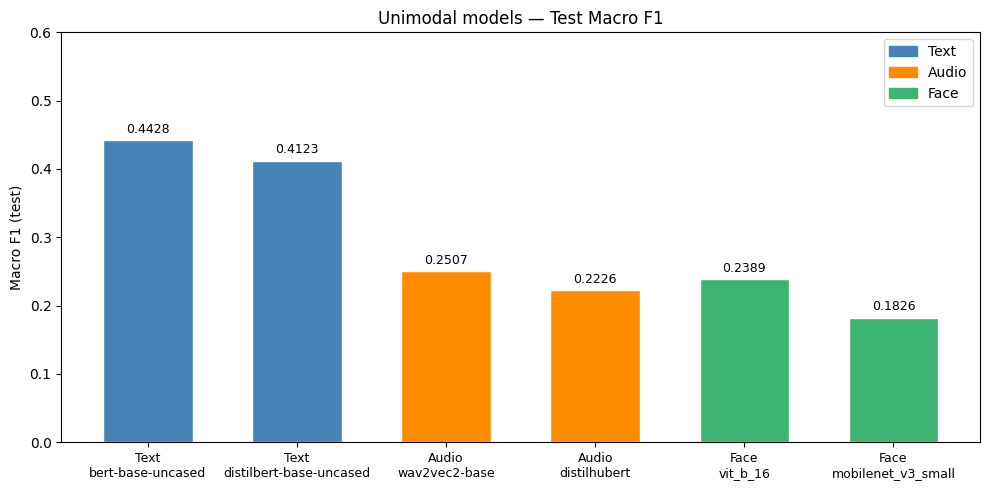

In [22]:
colors = {'Text': 'steelblue', 'Audio': 'darkorange', 'Face': 'mediumseagreen'}
bar_colors = [colors[m] for m in unimodal_df['modality']]

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(unimodal_df))
bars = ax.bar(x, unimodal_df['test_macro_f1'], color=bar_colors, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [f"{row.modality}\n{row.model.split('/')[-1]}" for row in unimodal_df.itertuples()],
    fontsize=9,
)
ax.set_ylim(0, 0.6)
ax.set_ylabel('Macro F1 (test)')
ax.set_title('Unimodal models — Test Macro F1')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l, c in colors.items()], loc='upper right')

plt.tight_layout()
plt.show()

### 1d — Per-class breakdown for each unimodal model

In [23]:
CLASSES = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

def load_per_class(run_dir, json_name='eval_metrics.json'):
    path = os.path.join(run_dir, json_name)
    if not os.path.exists(path):
        return None
    data = load_json(path)
    report = data.get('report', data)  # eval_metrics may embed report or be a report itself
    rows = []
    for cls in CLASSES:
        if cls in report:
            r = report[cls]
            rows.append({'class': cls,
                         'precision': round(r['precision'], 4),
                         'recall':    round(r['recall'],    4),
                         'f1-score':  round(r['f1-score'],  4),
                         'support':   int(r['support'])})
    return pd.DataFrame(rows) if rows else None

# Show per-class tables for each model
for model_name in MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT, VERSION, slugify(model_name))
    report_path = os.path.join(run_dir, 'classification_report.json')
    df_pc = load_per_class(run_dir, 'classification_report.json')
    if df_pc is not None:
        print(f'\n── {model_name} (Text) ──')
        print(df_pc.to_string(index=False))

for model_name in AUDIO_MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT_AUDIO, VERSION, slugify(model_name))
    df_pc = load_per_class(run_dir, 'classification_report.json')
    if df_pc is not None:
        print(f'\n── {model_name} (Audio) ──')
        print(df_pc.to_string(index=False))

for model_name in FACE_MODELS_TO_RUN:
    run_dir = os.path.join(EXP_ROOT_FACE, VERSION, slugify(model_name))
    df_pc = load_per_class(run_dir, 'classification_report.json')
    if df_pc is not None:
        print(f'\n── {model_name} (Face) ──')
        print(df_pc.to_string(index=False))

---
## 2 — Late Fusion Results

Two combos are evaluated:
- **Heavy**: BERT + wav2vec2-base + ViT-B/16
- **Light**: DistilBERT + DistilHuBERT + MobileNetV3-Small

Run `30_late_fusion.ipynb` with `COMBO="heavy"` then `COMBO="light"` to produce these results.

In [24]:
late_records = []

for combo in COMBOS:
    out_dir = os.path.join(LATE_FUSION_ROOT, combo)
    avg_path = os.path.join(out_dir, 'avg_ensemble_metrics.json')
    wt_path  = os.path.join(out_dir, 'weighted_ensemble_metrics.json')
    w_path   = os.path.join(out_dir, 'weights.json')

    if not os.path.exists(avg_path):
        print(f'  [skip] no late fusion results for combo={combo}')
        print(f'         → run notebook 30 with COMBO="{combo}"')
        continue

    avg_m = load_json(avg_path)
    wt_m  = safe_load_json(wt_path, {})
    w     = safe_load_json(w_path, {})

    late_records.append({
        'combo':              combo,
        'strategy':           'Average Ensemble',
        'text_w':             0.33, 'audio_w': 0.33, 'face_w': 0.33,
        'accuracy':           round(avg_m.get('accuracy', float('nan')), 4),
        'macro_f1':           round(avg_m.get('macro_f1', float('nan')), 4),
        'weighted_f1':        round(avg_m.get('weighted_f1', float('nan')), 4),
        'num_utterances':     avg_m.get('num_utterances', None),
    })
    late_records.append({
        'combo':              combo,
        'strategy':           'Weighted Ensemble',
        'text_w':             w.get('text', float('nan')),
        'audio_w':            w.get('audio', float('nan')),
        'face_w':             w.get('face', float('nan')),
        'accuracy':           round(wt_m.get('accuracy', float('nan')), 4),
        'macro_f1':           round(wt_m.get('macro_f1', float('nan')), 4),
        'weighted_f1':        round(wt_m.get('weighted_f1', float('nan')), 4),
        'num_utterances':     wt_m.get('num_utterances', None),
    })

if late_records:
    late_df = pd.DataFrame(late_records)
    display(late_df.to_string(index=False))
else:
    late_df = pd.DataFrame()
    print('No late fusion results available yet.')

'combo          strategy  text_w  audio_w  face_w  accuracy  macro_f1  weighted_f1  num_utterances\nheavy  Average Ensemble    0.33     0.33    0.33    0.6183    0.4168       0.5959            2481\nheavy Weighted Ensemble    0.40     0.10    0.50    0.6332    0.4597       0.6209            2481\nlight  Average Ensemble    0.33     0.33    0.33    0.6002    0.4067       0.5847            2481\nlight Weighted Ensemble    0.40     0.30    0.30    0.5994    0.4155       0.5897            2481'

### 2a — Late fusion confusion matrices

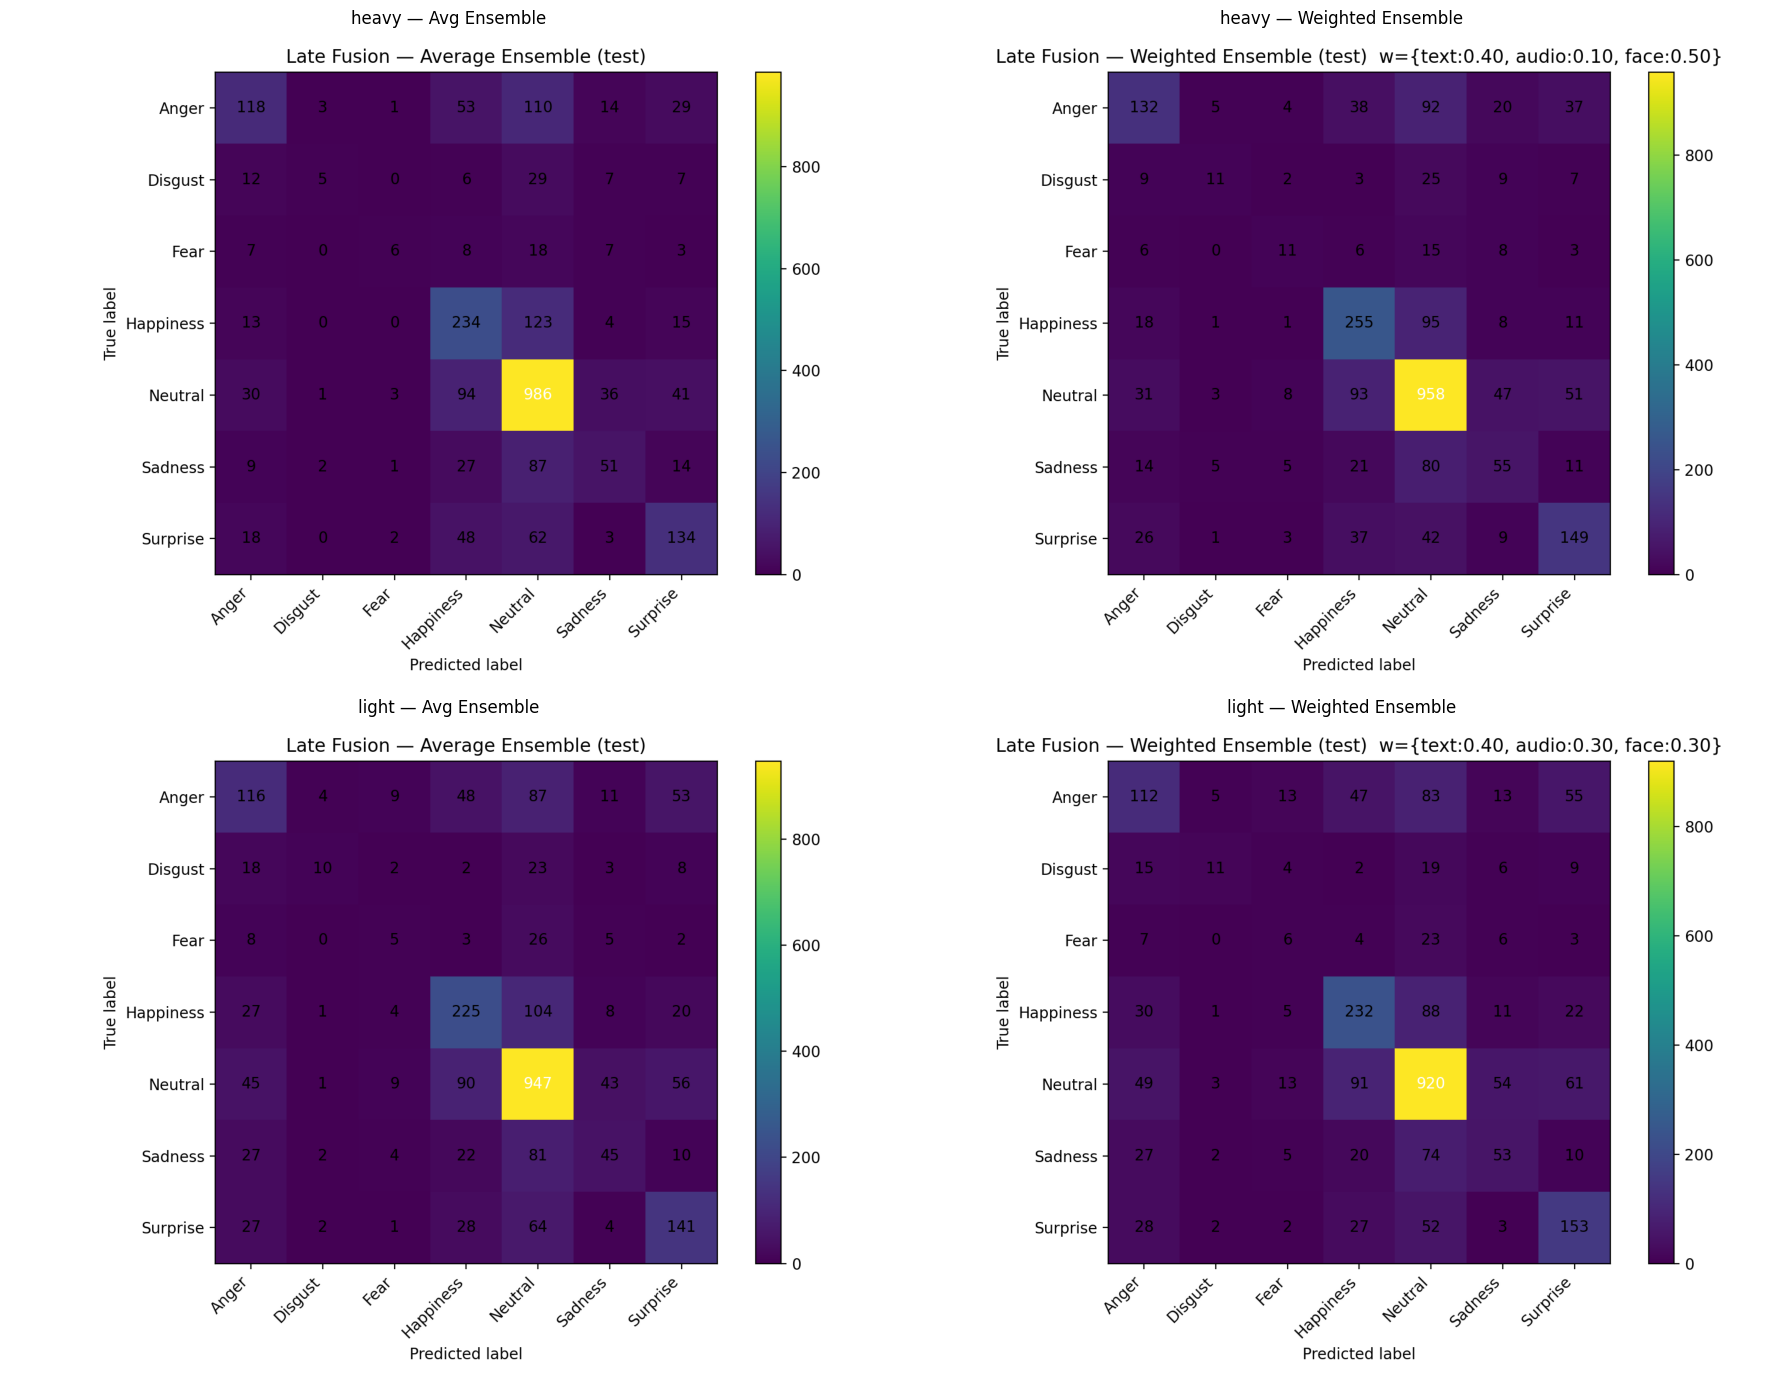

In [25]:
n_combos = sum(1 for c in COMBOS if os.path.exists(os.path.join(LATE_FUSION_ROOT, c, 'avg_ensemble_cm.png')))

if n_combos == 0:
    print('No late fusion confusion matrices found.')
else:
    fig, axes = plt.subplots(n_combos, 2, figsize=(18, 7 * n_combos))
    if n_combos == 1:
        axes = [axes]  # ensure 2D indexing

    row = 0
    for combo in COMBOS:
        out_dir = os.path.join(LATE_FUSION_ROOT, combo)
        for col, name in enumerate(['avg_ensemble', 'weighted_ensemble']):
            img_path = os.path.join(out_dir, f'{name}_cm.png')
            ax = axes[row][col]
            if os.path.exists(img_path):
                ax.imshow(mpimg.imread(img_path))
                ax.set_title(f'{combo} — {name.replace("_", " ").title()}')
            else:
                ax.set_title(f'{combo} — {name} (not found)')
            ax.axis('off')
        row += 1

    plt.tight_layout()
    plt.show()

---
## 3 — Intermediate Fusion Results

Two combos are evaluated (same backbones as late fusion).

Run `31_intermediate_fusion.ipynb` with `COMBO="heavy"` then `COMBO="light"` to produce these results.

In [26]:
inter_records = []

for combo in COMBOS:
    out_dir = os.path.join(INTER_FUSION_ROOT, combo)
    test_path   = os.path.join(out_dir, 'test_metrics.json')
    config_path = os.path.join(out_dir, 'config.json')

    if not os.path.exists(test_path):
        print(f'  [skip] no intermediate fusion results for combo={combo}')
        print(f'         → run notebook 31 with COMBO="{combo}"')
        continue

    tm  = load_json(test_path)
    cfg = safe_load_json(config_path, {})

    emb_dims  = cfg.get('emb_dims', {})
    total_dim = cfg.get('total_dim', sum(emb_dims.values()) if emb_dims else None)

    inter_records.append({
        'combo':          combo,
        'emb_dim_total':  total_dim,
        'mlp_epochs':     cfg.get('mlp_epochs', None),
        'accuracy':       round(tm.get('accuracy', float('nan')), 4),
        'macro_f1':       round(tm.get('macro_f1', float('nan')), 4),
        'weighted_f1':    round(tm.get('weighted_f1', float('nan')), 4),
        'num_utterances': tm.get('num_utterances', None),
    })

if inter_records:
    inter_df = pd.DataFrame(inter_records)
    print(inter_df.to_string(index=False))
else:
    inter_df = pd.DataFrame()
    print('No intermediate fusion results available yet.')

combo  emb_dim_total  mlp_epochs  accuracy  macro_f1  weighted_f1  num_utterances
heavy           1792          50    0.6191    0.4533       0.6163            2481
light           2048          50    0.5784    0.4098       0.5792            2481


### 3a — Intermediate fusion training curves

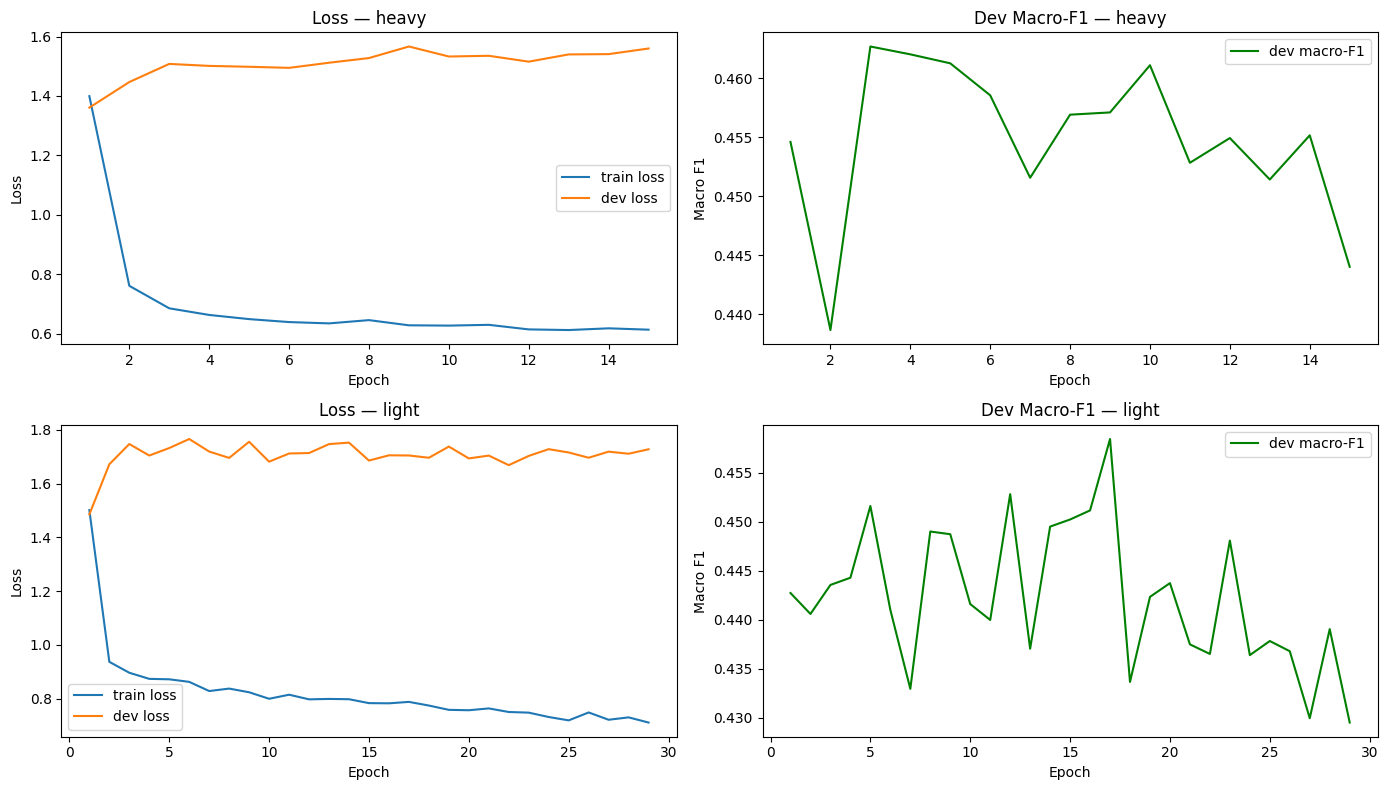

In [27]:
available_combos = [
    c for c in COMBOS
    if os.path.exists(os.path.join(INTER_FUSION_ROOT, c, 'history.csv'))
]

if not available_combos:
    print('No training history files found.')
else:
    fig, axes = plt.subplots(len(available_combos), 2,
                             figsize=(14, 4 * len(available_combos)), squeeze=False)

    for row, combo in enumerate(available_combos):
        hist = pd.read_csv(os.path.join(INTER_FUSION_ROOT, combo, 'history.csv'))

        ax1 = axes[row][0]
        ax1.plot(hist['epoch'], hist['train_loss'], label='train loss')
        ax1.plot(hist['epoch'], hist['dev_loss'],   label='dev loss')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
        ax1.set_title(f'Loss — {combo}'); ax1.legend()

        ax2 = axes[row][1]
        ax2.plot(hist['epoch'], hist['dev_macro_f1'], color='green', label='dev macro-F1')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
        ax2.set_title(f'Dev Macro-F1 — {combo}'); ax2.legend()

    plt.tight_layout()
    plt.show()

### 3b — Intermediate fusion confusion matrices

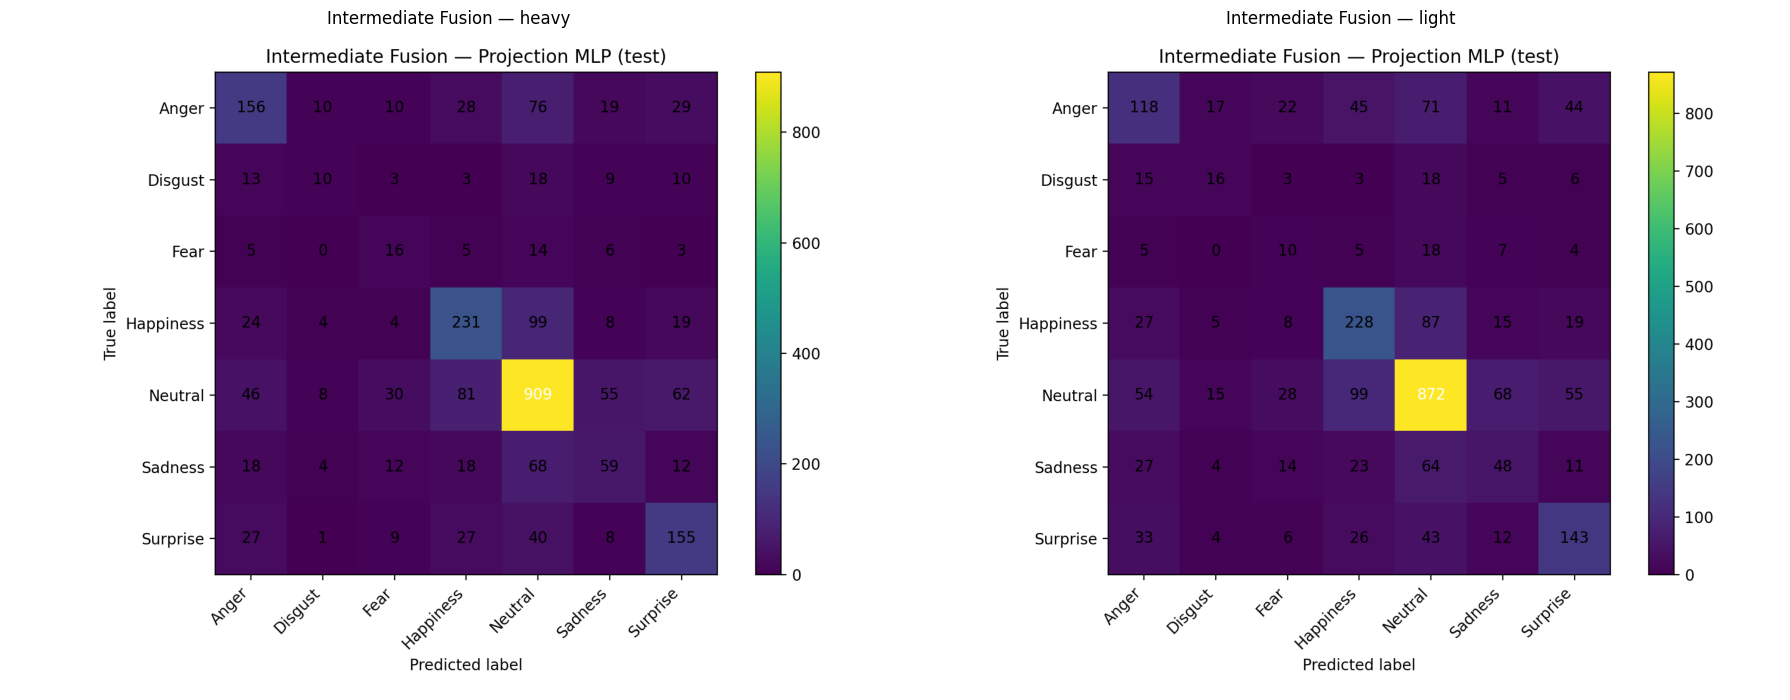

In [28]:
cm_combos = [
    c for c in COMBOS
    if os.path.exists(os.path.join(INTER_FUSION_ROOT, c, 'confusion_matrix_test.png'))
]

if not cm_combos:
    print('No intermediate fusion confusion matrices found.')
else:
    fig, axes = plt.subplots(1, len(cm_combos), figsize=(9 * len(cm_combos), 7))
    if len(cm_combos) == 1:
        axes = [axes]

    for ax, combo in zip(axes, cm_combos):
        img_path = os.path.join(INTER_FUSION_ROOT, combo, 'confusion_matrix_test.png')
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f'Intermediate Fusion — {combo}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [29]:
gated_records = []

GATED_FUSION_ROOT = f'../experiments/fusion/gated'
VARIANTS = ['light', 'heavy']

# Load all combinations of backbone (COMBO) and gating (VARIANT)
for variant in VARIANTS:
    for combo in COMBOS:
        out_dir = os.path.join(GATED_FUSION_ROOT, variant, VERSION, combo)
        test_path   = os.path.join(out_dir, 'test_metrics.json')
        config_path = os.path.join(out_dir, 'config.json')

        if not os.path.exists(test_path):
            print(f'  [skip] no gated fusion results for variant={variant}, combo={combo}')
            continue

        tm  = load_json(test_path)
        cfg = safe_load_json(config_path, {})

        emb_dims  = cfg.get('emb_dims', {})
        total_dim = cfg.get('total_dim', sum(emb_dims.values()) if emb_dims else None)

        gated_records.append({
            'combo':          combo,
            'variant':        variant,
            'emb_dim_total':  total_dim,
            'mlp_epochs':     cfg.get('mlp_epochs', None),
            'accuracy':       round(tm.get('accuracy', float('nan')), 4),
            'macro_f1':       round(tm.get('macro_f1', float('nan')), 4),
            'weighted_f1':    round(tm.get('weighted_f1', float('nan')), 4),
            'num_utterances': tm.get('num_utterances', None),
        })

if gated_records:
    gated_df = pd.DataFrame(gated_records)
    print(gated_df.to_string(index=False))
else:
    gated_df = pd.DataFrame()
    print('No gated fusion results available yet.')

combo variant  emb_dim_total mlp_epochs  accuracy  macro_f1  weighted_f1  num_utterances
heavy   light           1792       None    0.5857    0.4316       0.5954            2481
light   light           2048       None    0.5699    0.4157       0.5801            2481
heavy   heavy           1792       None    0.5885    0.4322       0.5965            2481
light   heavy           2048       None    0.5607    0.4090       0.5669            2481


### 4b — Gated fusion confusion matrices

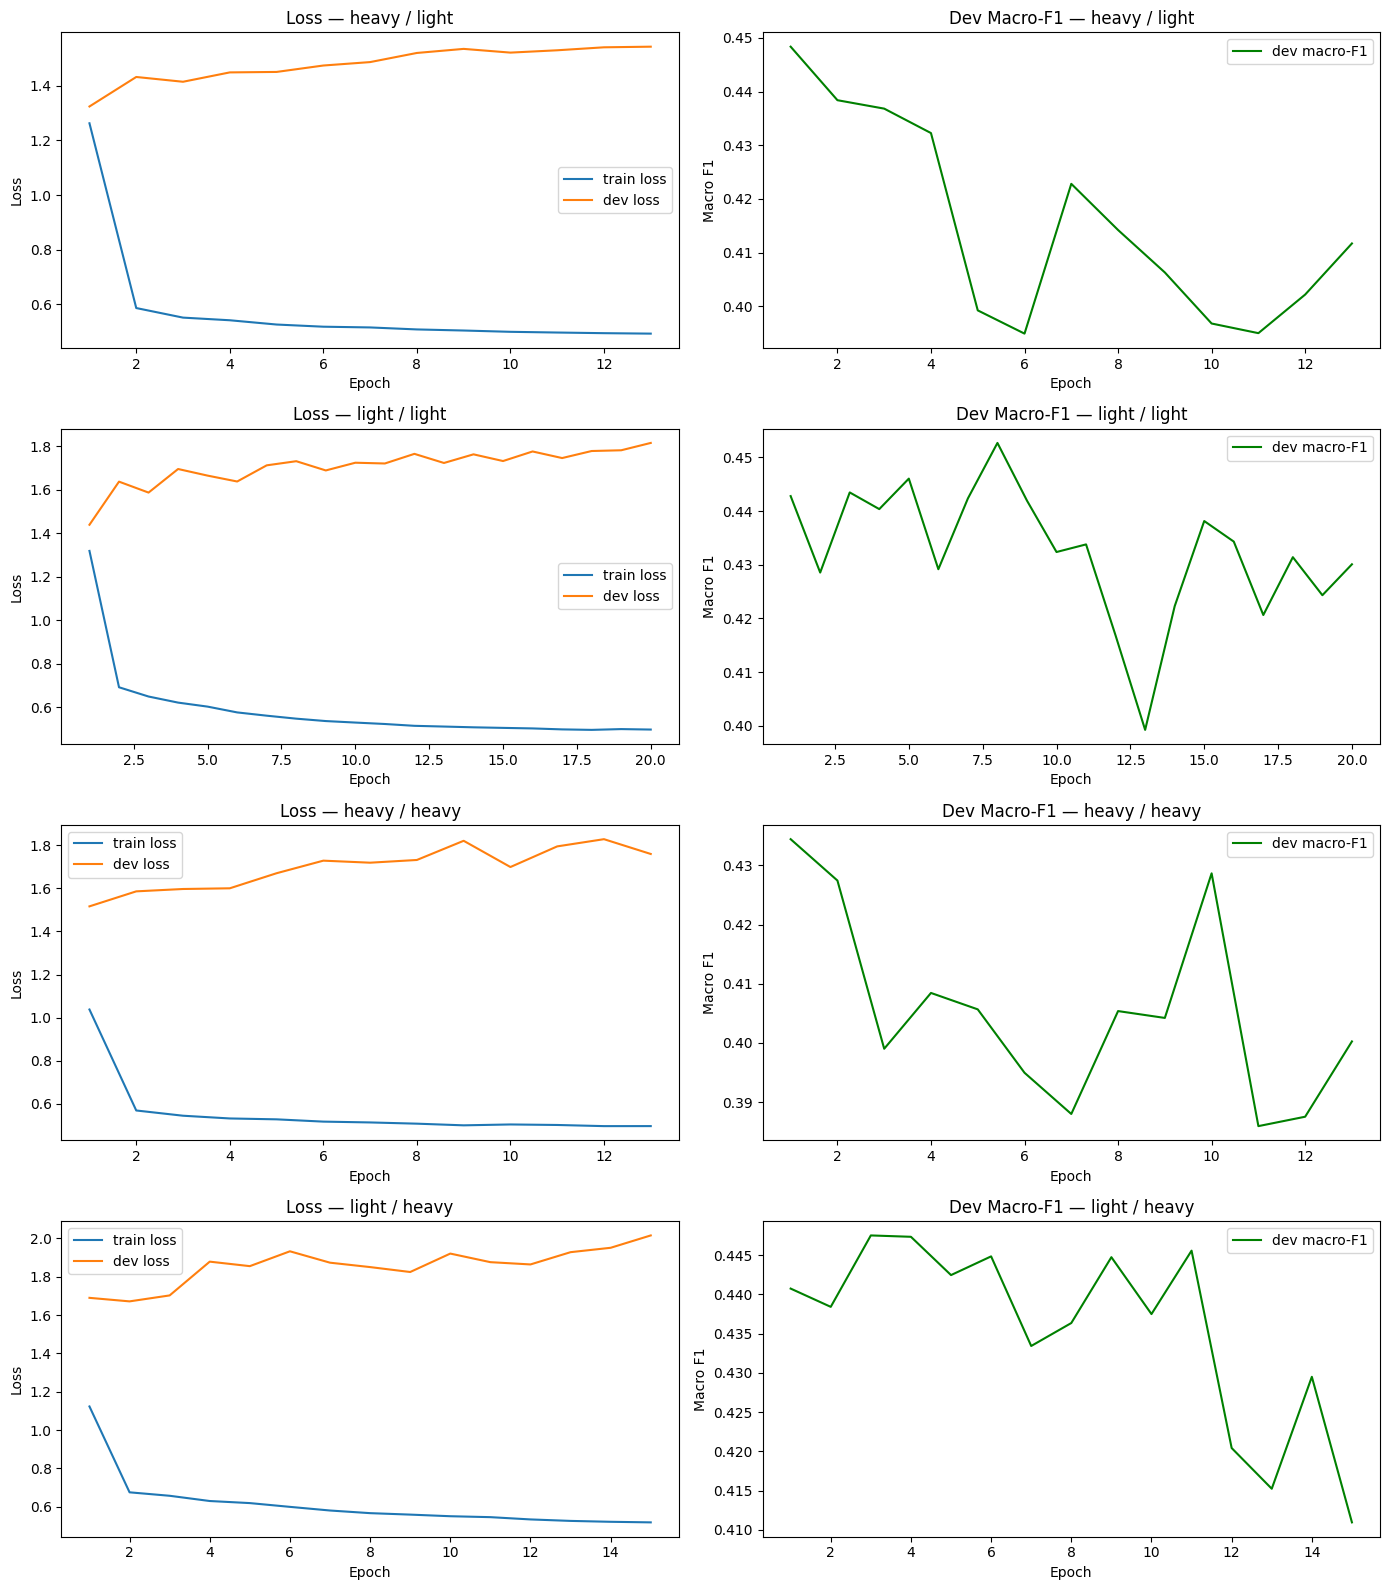

In [30]:
available_gated_combos = []
for variant in VARIANTS:
    for combo in COMBOS:
        out_dir = os.path.join(GATED_FUSION_ROOT, variant, VERSION, combo)
        if os.path.exists(os.path.join(out_dir, 'history.csv')):
            available_gated_combos.append((variant, combo))

if not available_gated_combos:
    print('No gated fusion training history files found.')
else:
    fig, axes = plt.subplots(len(available_gated_combos), 2,
                             figsize=(14, 4 * len(available_gated_combos)), squeeze=False)

    for row, (variant, combo) in enumerate(available_gated_combos):
        out_dir = os.path.join(GATED_FUSION_ROOT, variant, VERSION, combo)
        hist = pd.read_csv(os.path.join(out_dir, 'history.csv'))

        ax1 = axes[row][0]
        ax1.plot(hist['epoch'], hist['train_loss'], label='train loss')
        ax1.plot(hist['epoch'], hist['dev_loss'],   label='dev loss')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
        ax1.set_title(f'Loss — {combo} / {variant}'); ax1.legend()

        ax2 = axes[row][1]
        ax2.plot(hist['epoch'], hist['dev_macro_f1'], color='green', label='dev macro-F1')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
        ax2.set_title(f'Dev Macro-F1 — {combo} / {variant}'); ax2.legend()

    plt.tight_layout()
    plt.show()

### 4a — Gated fusion training curves

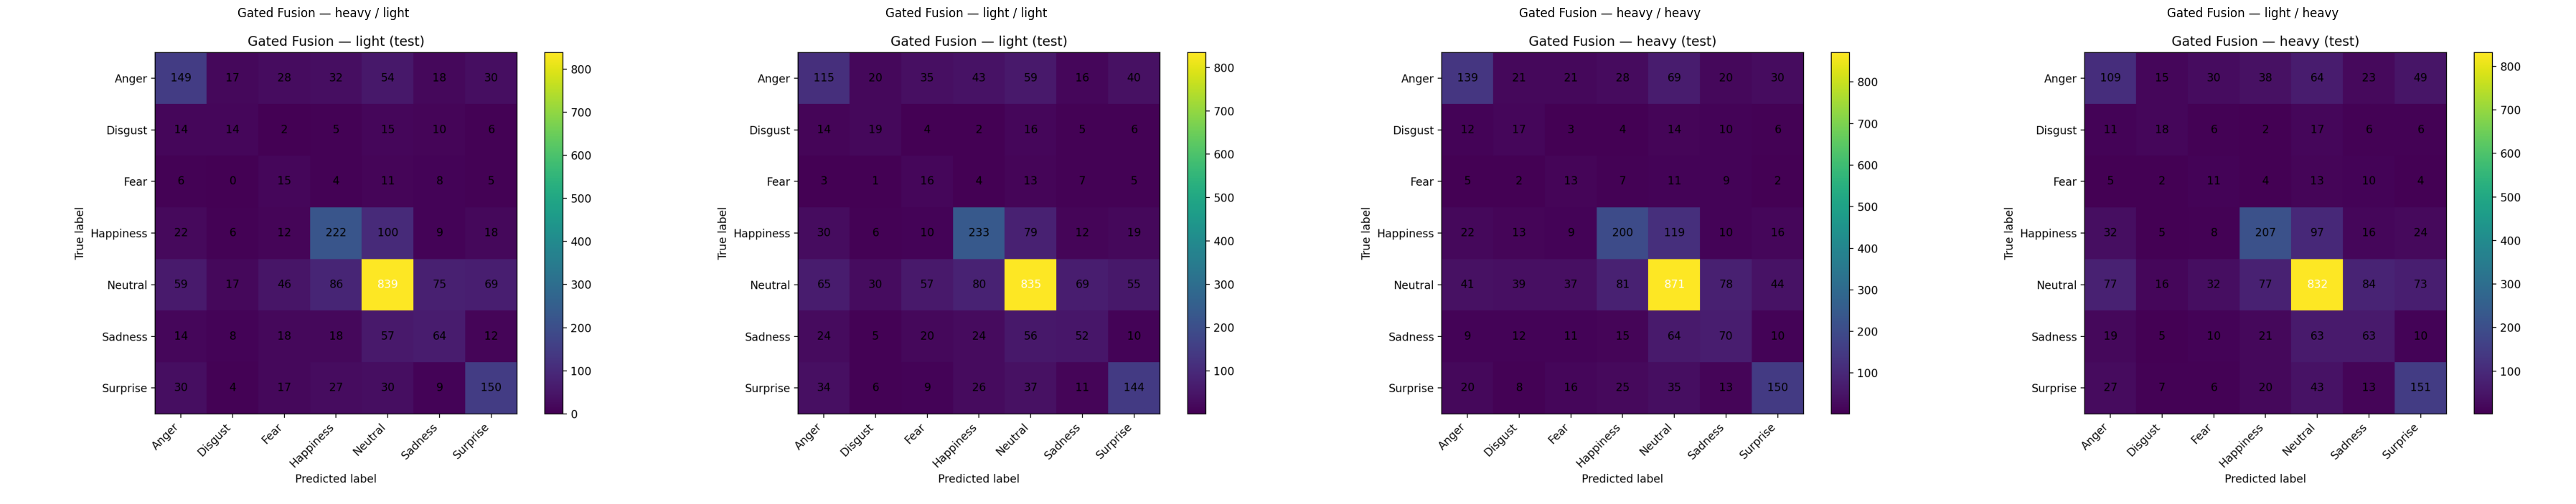

In [31]:
cm_gated_combos = []
for variant in VARIANTS:
    for combo in COMBOS:
        out_dir = os.path.join(GATED_FUSION_ROOT, variant, VERSION, combo)
        if os.path.exists(os.path.join(out_dir, 'confusion_matrix_test.png')):
            cm_gated_combos.append((variant, combo))

if not cm_gated_combos:
    print('No gated fusion confusion matrices found.')
else:
    fig, axes = plt.subplots(1, len(cm_gated_combos), figsize=(9 * len(cm_gated_combos), 7))
    if len(cm_gated_combos) == 1:
        axes = [axes]

    for ax, (variant, combo) in zip(axes, cm_gated_combos):
        out_dir = os.path.join(GATED_FUSION_ROOT, variant, VERSION, combo)
        img_path = os.path.join(out_dir, 'confusion_matrix_test.png')
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f'Gated Fusion — {combo} / {variant}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

---
## 4 — Gated Fusion Results

Two combos are evaluated (same backbones as late and intermediate fusion).

Run `32_gated_fusion.ipynb` with `COMBO="heavy"` then `COMBO="light"` to produce these results.

---
## 5 — Master Comparison Table

All methods side-by-side, sorted by Test Macro F1.

In [32]:
master_rows = []

# ── Unimodal ──────────────────────────────────────────────────────────────────
for row in unimodal_df.itertuples():
    master_rows.append({
        'Method':       f'{row.modality} — {row.model.split("/")[-1]}',
        'Type':         'Unimodal',
        'Combo':        '—',
        'Variant':      '—',
        'Accuracy':     row.test_accuracy,
        'Macro F1':     row.test_macro_f1,
        'Weighted F1':  row.test_weighted_f1,
    })

# ── Late Fusion ───────────────────────────────────────────────────────────────
for row in late_df.itertuples() if not late_df.empty else []:
    master_rows.append({
        'Method':       f'Late Fusion — {row.strategy}',
        'Type':         'Late Fusion',
        'Combo':        row.combo,
        'Variant':      '—',
        'Accuracy':     row.accuracy,
        'Macro F1':     row.macro_f1,
        'Weighted F1':  row.weighted_f1,
    })

# ── Intermediate Fusion ───────────────────────────────────────────────────────
for row in inter_df.itertuples() if not inter_df.empty else []:
    master_rows.append({
        'Method':       'Intermediate Fusion — MLP',
        'Type':         'Intermediate Fusion',
        'Combo':        row.combo,
        'Variant':      '—',
        'Accuracy':     row.accuracy,
        'Macro F1':     row.macro_f1,
        'Weighted F1':  row.weighted_f1,
    })

# ── Gated Fusion ──────────────────────────────────────────────────────────────
for row in gated_df.itertuples() if not gated_df.empty else []:
    master_rows.append({
        'Method':       'Gated Fusion — Gated MLP',
        'Type':         'Gated Fusion',
        'Combo':        row.combo,
        'Variant':      row.variant,
        'Accuracy':     row.accuracy,
        'Macro F1':     row.macro_f1,
        'Weighted F1':  row.weighted_f1,
    })

master_df = pd.DataFrame(master_rows)
master_df = master_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)
master_df

,Method,Type,Combo,Variant,Accuracy,Macro F1,Weighted F1
0,Late Fusion — Weighted Ensemble,Late Fusion,heavy,—,0.6332,0.4597,0.6209
1,Intermediate Fusion — MLP,Intermediate Fusion,heavy,—,0.6191,0.4533,0.6163
2,Text — bert-base-uncased,Unimodal,—,—,0.6165,0.4428,0.6085
3,Gated Fusion — Gated MLP,Gated Fusion,heavy,heavy,0.5885,0.4322,0.5965
4,Gated Fusion — Gated MLP,Gated Fusion,heavy,light,0.5857,0.4316,0.5954
5,Late Fusion — Average Ensemble,Late Fusion,heavy,—,0.6183,0.4168,0.5959
6,Gated Fusion — Gated MLP,Gated Fusion,light,light,0.5699,0.4157,0.5801
7,Late Fusion — Weighted Ensemble,Late Fusion,light,—,0.5994,0.4155,0.5897
8,Text — distilbert-base-uncased,Unimodal,—,—,0.5877,0.4123,0.5885
9,Intermediate Fusion — MLP,Intermediate Fusion,light,—,0.5784,0.4098,0.5792


### 5a — Comparison bar chart

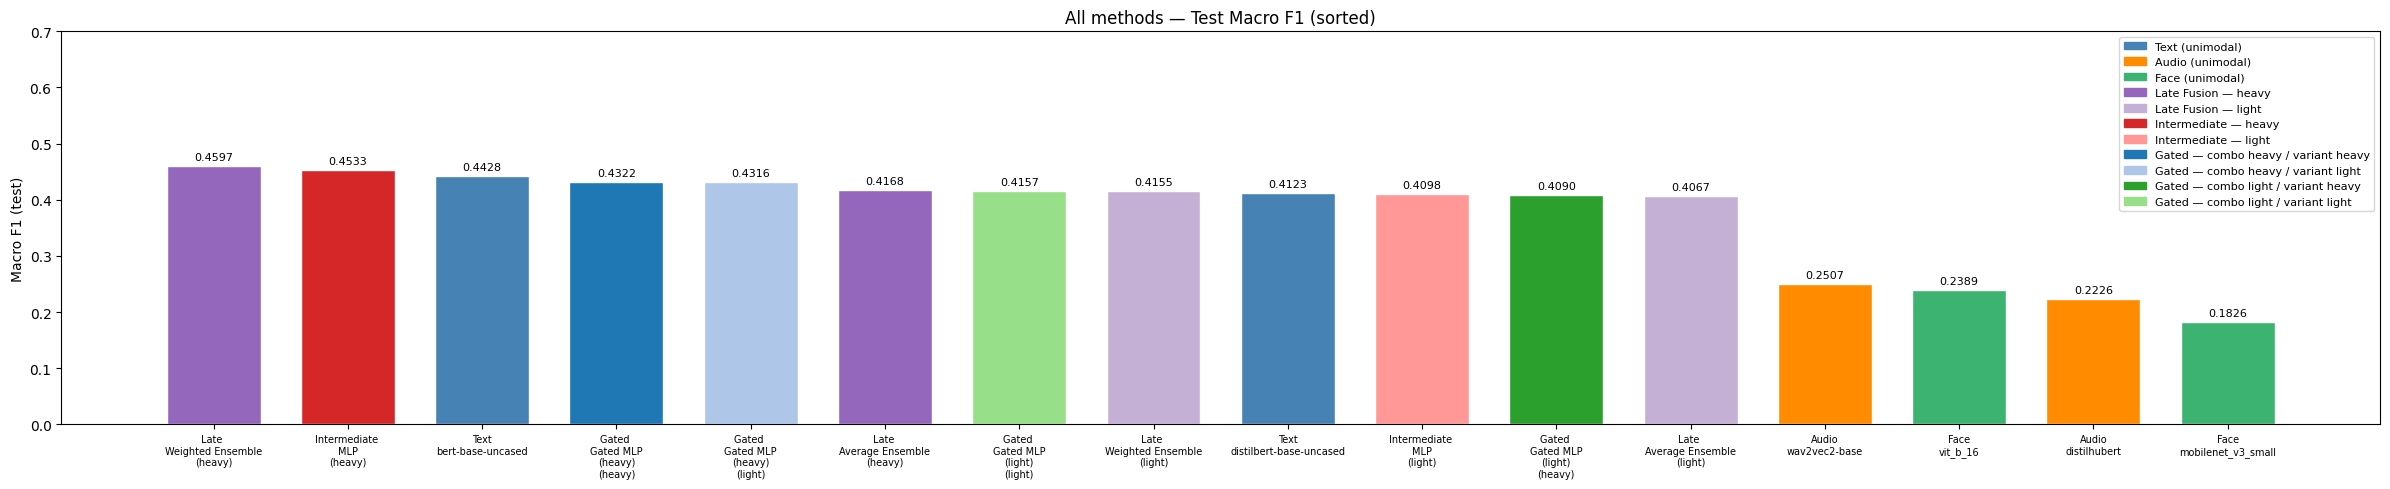

In [33]:
type_colors = {
    'Unimodal':             {'Text': 'steelblue', 'Audio': 'darkorange', 'Face': 'mediumseagreen'},
    'Late Fusion':          {'heavy': '#9467bd', 'light': '#c5b0d5'},
    'Intermediate Fusion':  {'heavy': '#d62728', 'light': '#ff9896'},
    'Gated Fusion':         {('heavy', 'heavy'): '#1f77b4', ('heavy', 'light'): '#aec7e8',
                             ('light', 'heavy'): '#2ca02c', ('light', 'light'): '#98df8a'},
}

def row_color(row):
    t = row['Type']
    c = row['Combo']
    v = row['Variant']
    if t == 'Unimodal':
        mod = row['Method'].split(' — ')[0]
        return type_colors['Unimodal'].get(mod, 'gray')
    elif t == 'Gated Fusion':
        return type_colors.get(t, {}).get((c, v), 'gray')
    return type_colors.get(t, {}).get(c, 'gray')

bar_colors = [row_color(r) for _, r in master_df.iterrows()]

fig, ax = plt.subplots(figsize=(max(12, len(master_df) * 1.5), 5))
x = range(len(master_df))
bars = ax.bar(x, master_df['Macro F1'], color=bar_colors, edgecolor='white', width=0.7)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)

labels = []
for _, row in master_df.iterrows():
    m = row['Method'].replace('Fusion — ', '\n').replace(' — ', '\n')
    c = f"({row['Combo']})" if row['Combo'] != '—' else ''
    v = f"({row['Variant']})" if row['Variant'] != '—' else ''
    label_str = m
    if c:
        label_str = f'{m}\n{c}'
    if v:
        label_str = f'{label_str}\n{v}' if c else f'{m}\n{v}'
    labels.append(label_str)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylim(0, 0.7)
ax.set_ylabel('Macro F1 (test)')
ax.set_title('All methods — Test Macro F1 (sorted)')

from matplotlib.patches import Patch
legend_elems = [
    Patch(color='steelblue',   label='Text (unimodal)'),
    Patch(color='darkorange',  label='Audio (unimodal)'),
    Patch(color='mediumseagreen', label='Face (unimodal)'),
    Patch(color='#9467bd',     label='Late Fusion — heavy'),
    Patch(color='#c5b0d5',     label='Late Fusion — light'),
    Patch(color='#d62728',     label='Intermediate — heavy'),
    Patch(color='#ff9896',     label='Intermediate — light'),
    Patch(color='#1f77b4',     label='Gated — combo heavy / variant heavy'),
    Patch(color='#aec7e8',     label='Gated — combo heavy / variant light'),
    Patch(color='#2ca02c',     label='Gated — combo light / variant heavy'),
    Patch(color='#98df8a',     label='Gated — combo light / variant light'),
]
ax.legend(handles=legend_elems, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

---
## 6 — Learning curves (unimodal models)

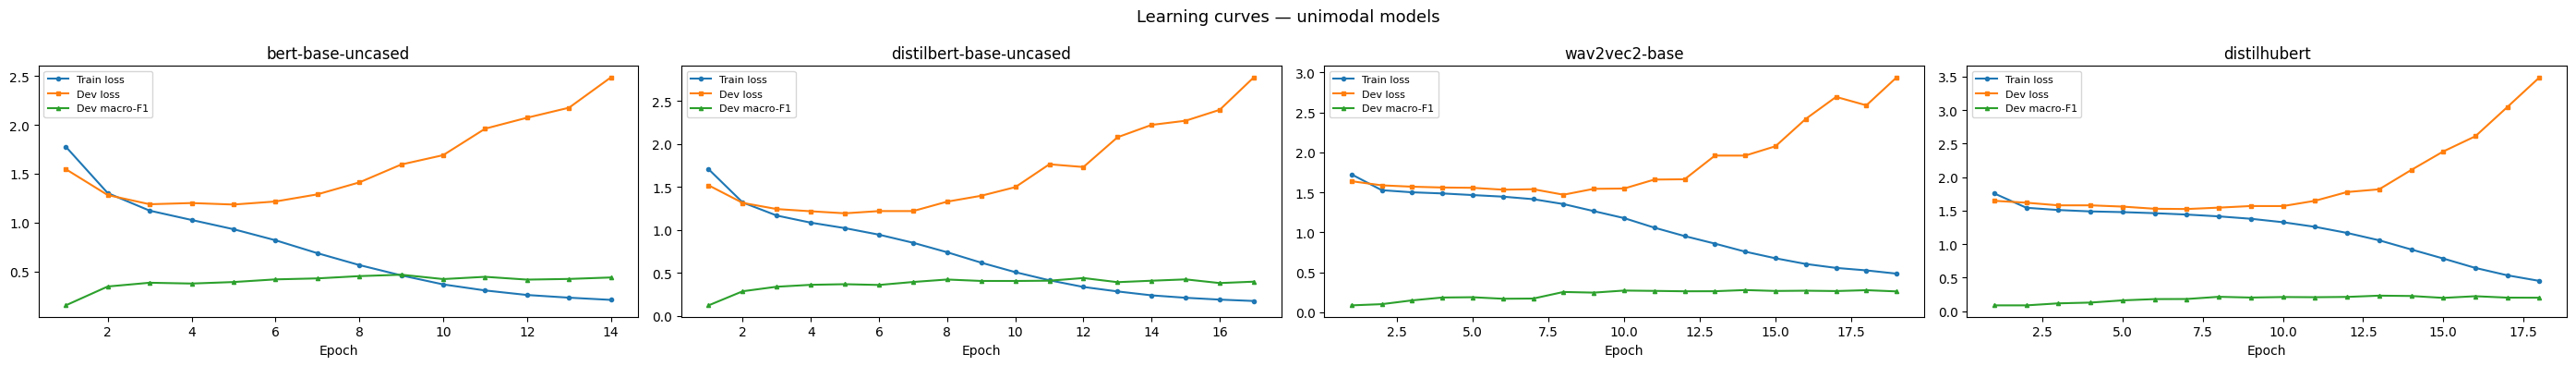

In [34]:
histories = {}
all_models = [
    (EXP_ROOT,       MODELS_TO_RUN),
    (EXP_ROOT_AUDIO, AUDIO_MODELS_TO_RUN),
]
# Face models use a different history key name
for root, model_list in all_models:
    for model_name in model_list:
        h_path = os.path.join(root, VERSION, slugify(model_name), 'history.csv')
        if os.path.exists(h_path):
            histories[model_name] = pd.read_csv(h_path)

if not histories:
    print('No history.csv files found.')
else:
    n = len(histories)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 4), squeeze=False)
    for ax, (model_name, hist) in zip(axes[0], histories.items()):
        ax.plot(hist['epoch'], hist['train_loss'],   label='Train loss',   marker='o', markersize=3)
        ax.plot(hist['epoch'], hist['dev_loss'],     label='Dev loss',     marker='s', markersize=3)
        ax.plot(hist['epoch'], hist['dev_macro_f1'], label='Dev macro-F1', marker='^', markersize=3)
        ax.set_xlabel('Epoch')
        ax.set_title(model_name.split('/')[-1])
        ax.legend(fontsize=8)
    plt.suptitle('Learning curves — unimodal models', fontsize=13)
    plt.tight_layout()
    plt.show()